In [187]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [188]:
diagrams_path = './diagrams/'

In [189]:
boss_rand_df = pd.read_csv('./experiment-results/boss-rand-results.csv')
boss_bixi_df = pd.read_csv('./experiment-results/boss-bixi-results.csv')
competition_rand_df = pd.read_csv('./experiment-results/competition-rand-results.csv')
competition_bixi_df = pd.read_csv('./experiment-results/competition-bixi-results.csv')

rand_df = pd.merge(boss_rand_df, competition_rand_df, left_on='table name', right_on='table name')
bixi_df = pd.merge(boss_bixi_df, competition_bixi_df, left_on='table name', right_on='table name')

print(rand_df)
print()
print(bixi_df)

  table name  boss data in  boss round trip  boss materialise columns  \
0       64 b         67224           117285                    129121   
1       1 mb         68075           321523                    334894   
2      10 mb         68133          2607503                   2606172   
3     100 mb         68339         13342084                  13353095   
4       1 gb         76411        151775432                 145692351   
5       2 gb         85038        265504523                 288523975   

   boss materialise matrix  boss matrix vector product  \
0                   166052                      204639   
1                   260349                      783442   
2                  2033577                     2835154   
3                 79228307                    41687670   
4                739076365                   432153357   
5               1542633549                   825659491   

   boss matrix matrix product  pandas data in  duckdb data in  sqlite data in  
0

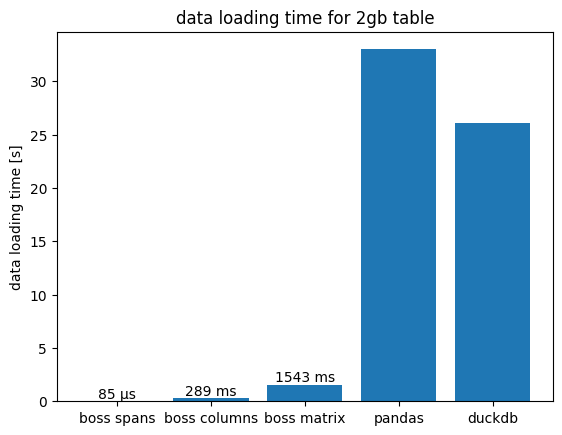

In [190]:
vendor_tasks = ['boss data in', 'boss materialise columns', 'boss materialise matrix', 'pandas data in', 'duckdb data in']
vendors = ['boss spans', 'boss columns', 'boss matrix', 'pandas', 'duckdb']
times = [rand_df.loc[5, x] / (10 ** 9) for x in vendor_tasks]

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='data loading time [s]', title='data loading time for 2gb table')
# ax.bar_label(bar_container, fmt=lambda x: f'{x * (10 ** 3):.1f} ms')

rect = bar_container[0]
ax.annotate(f'{(rect.get_height() * (10 ** 6)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[2]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

plt.savefig(f'{diagrams_path}data-loading-2gb.png')
plt.show()

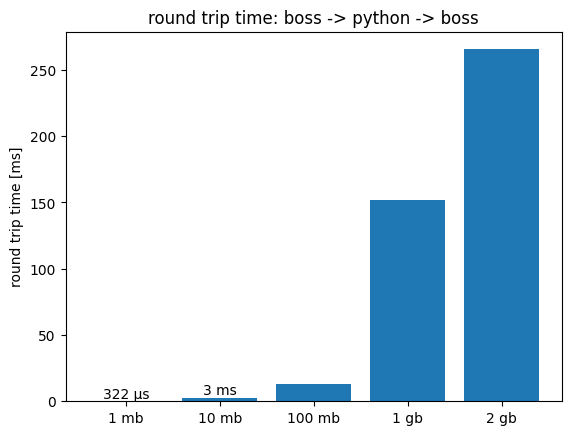

In [191]:
times = rand_df.loc[1:, 'boss round trip'] / (10 ** 6)
table_names = rand_df.loc[1:, 'table name']

fig, ax = plt.subplots()
bar_container = ax.bar(table_names, times)
ax.set(ylabel='round trip time [ms]', title='round trip time: boss -> python -> boss')

rect = bar_container[0]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height()):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

plt.savefig(f'{diagrams_path}round-trip.png')
plt.show()

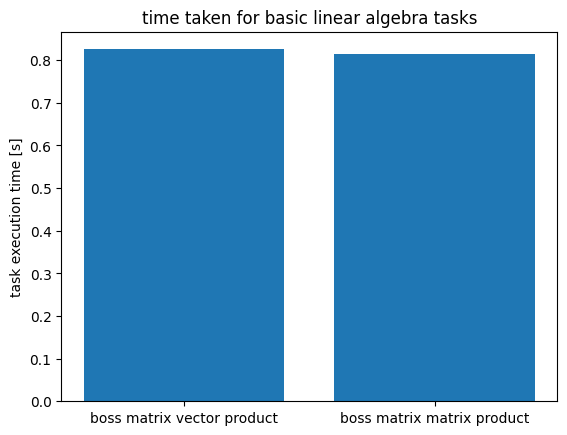

In [192]:
tasks = ['boss matrix vector product', 'boss matrix matrix product']
times = [rand_df.loc[5, x] / (10 ** 9) for x in tasks]

fig, ax = plt.subplots()
bar_container = ax.bar(tasks, times)
ax.set(ylabel='task execution time [s]', title='time taken for basic linear algebra tasks')

plt.savefig(f'{diagrams_path}linear-algebra.png')
plt.show()

In [193]:
task = 'predict duration from distance'
vendors = [
    'boss',
    'pandas',
    'duckdb',
    'sqlite',
]
bixi_full_tasks = [f'{x} {task}' for x in vendors]

loading_task = 'data in'
bixi_loading_tasks = [f'{x} {loading_task}' for x in vendors]

In [194]:
bixi_total_times = [bixi_df.loc[0, x] / (10 ** 9) for x in bixi_full_tasks]
bixi_loading_times = [bixi_df.loc[0, x] / (10 ** 9) for x in bixi_loading_tasks]
bixi_analytics_times = [bixi_total_times[i] - bixi_loading_times[i] for i in range(len(total_times))]

print('bixi_total_times')
print(bixi_total_times)
print('bixi_loading_times')
print(bixi_loading_times)
print('bixi_analytics_times')
print(bixi_analytics_times)

bixi_total_times
[1.385047755, 2.9924884745, 2.95209722825, 46.28636409633334]
bixi_loading_times
[6.1866e-05, 1.611856583857143, 1.560949031142857, 40.987593009666654]
bixi_analytics_times
[1.384985889, 1.380631890642857, 1.3911481971071429, 5.298771086666683]


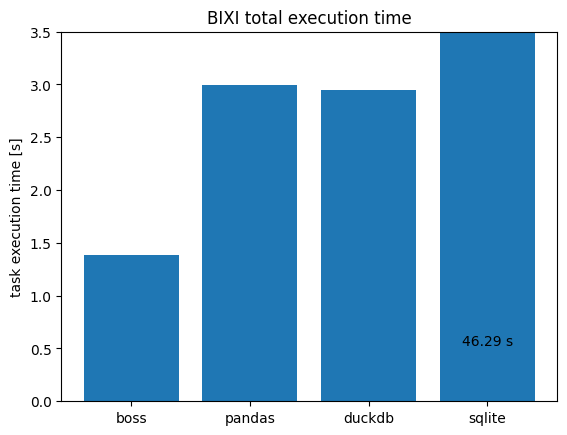

In [195]:
fig, ax = plt.subplots()
bar_container = ax.bar(vendors, bixi_total_times)
ax.set(ylabel='task execution time [s]', title='BIXI total execution time')
plt.ylim(top=3.5)

rect = bar_container[3]
ax.annotate(f'{rect.get_height():.2f} s',
            xy=(rect.get_x() + rect.get_width() / 2, 0.5),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

plt.savefig(f'{diagrams_path}bixi-total.png')
plt.show()

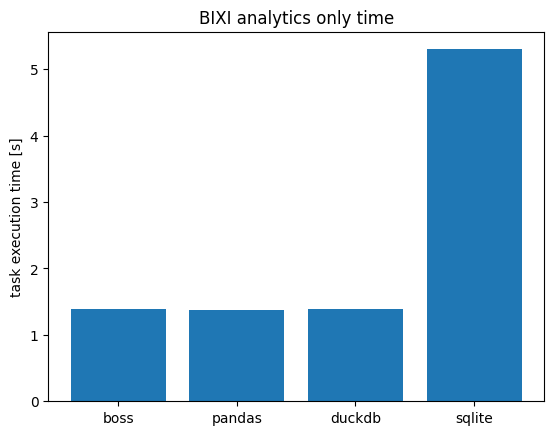

In [196]:
fig, ax = plt.subplots()
bar_container = ax.bar(vendors, bixi_analytics_times)
ax.set(ylabel='task execution time [s]', title='BIXI analytics only time')

plt.savefig(f'{diagrams_path}bixi-analytics.png')
plt.show()

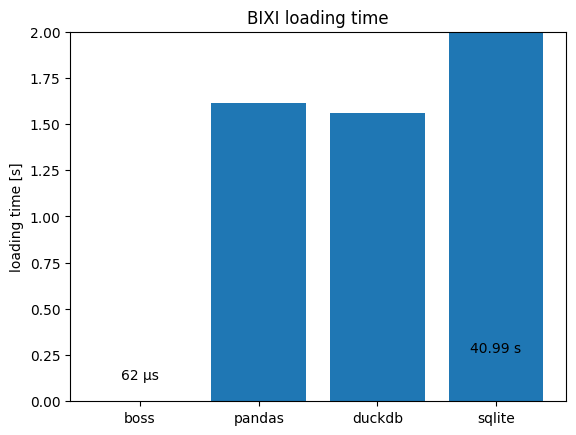

In [197]:
fig, ax = plt.subplots()
bar_container = ax.bar(vendors, bixi_loading_times)
ax.set(ylabel='loading time [s]', title='BIXI loading time')
plt.ylim(top=2)

rect = bar_container[0]
ax.annotate(f'{(rect.get_height() * (10 ** 6)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[3]
ax.annotate(f'{rect.get_height():.2f} s',
            xy=(rect.get_x() + rect.get_width() / 2, 0.25),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

plt.savefig(f'{diagrams_path}bixi-loading.png')
plt.show()